In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd
df = pd.read_csv(r"D:\walmart_combined.csv")
df.head()

,Order ID,ORDER_DATE,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit,profit percentage,Cost per product,SHIPPING DURATION(DAYS),order_date_clean
0,CA-2013-138688,13-Jun-13,17-Jun-13,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,14.9%,$8,4,2013-06-13
1,CA-2013-121755,16-Jan-13,20-Jan-13,Eric Hoffmann,United States,Los Angeles,California,Binders,Wilson Jones Active Use Binders,11.648,2,4.2224,14.9%,$7,4,2013-01-16
2,CA-2013-101343,18-Jul-13,23-Jul-13,Ruben Ausman,United States,Los Angeles,California,Storage,"Eldon Base for stackable storage shelf, platinum",77.880,2,3.8940,14.9%,$74,5,2013-07-18
3,CA-2012-135545,24-Nov-12,30-Nov-12,Kunst Miller,United States,Los Angeles,California,Accessories,Verbatim 25 GB 6x Blu-ray Single Layer Recorda...,13.980,2,6.1512,14.9%,$8,6,2012-11-24
4,CA-2013-109806,18-Sep-13,23-Sep-13,Jim Sink,United States,Los Angeles,California,Phones,Panasonic Kx-TS550,73.584,2,8.2782,14.9%,$65,5,2013-09-18


In [17]:
import pandas as pd
df = pd.read_csv(r"D:\walmart_combined.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3201 entries, 0 to 3200
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order ID                 3201 non-null   object 
 1   ORDER_DATE               3201 non-null   object 
 2   Ship Date                3201 non-null   object 
 3   Customer Name            3201 non-null   object 
 4   Country                  3201 non-null   object 
 5   City                     3201 non-null   object 
 6   State                    3201 non-null   object 
 7   Category                 3201 non-null   object 
 8   Product Name             3201 non-null   object 
 9   Sales                    3201 non-null   float64
 10  Quantity                 3201 non-null   int64  
 11  Profit                   3201 non-null   float64
 12  profit percentage        3201 non-null   object 
 13  Cost per product         3201 non-null   object 
 14  SHIPPING DURATION(DAYS) 

In [19]:
df.describe()

,Sales,Quantity,Profit,SHIPPING DURATION(DAYS)
count,3201.000000,3201.000000,3201.000000,3201.00000
mean,228.059731,3.795376,34.205515,3.68010
std,528.094680,2.232919,175.113716,2.27846
min,0.990000,1.000000,-3399.980000,-7.00000
25%,19.440000,2.000000,3.895000,2.00000
50%,60.120000,3.000000,11.151000,4.00000
75%,215.976000,5.000000,33.158400,5.00000
max,13999.960000,14.000000,6719.980800,7.00000


In [23]:
df.groupby("State")["Sales"].agg(['min', 'max', 'sum', 'mean']).sort_values(by="sum", ascending=False)


,min,max,sum,mean
State,,,,
California,0.990,8187.650,450567.5915,232.012148
Washington,1.344,13999.960,153138.0280,259.996652
Arizona,1.408,1879.960,34284.9050,158.726412
Colorado,1.080,2549.985,31285.2360,175.759753
Oregon,1.080,1487.040,17282.1020,144.017517
Nevada,3.640,4535.976,16642.9020,437.971105
Utah,5.040,1499.950,10575.0360,225.000766
Montana,8.288,2999.950,5583.2560,398.804000
New Mexico,4.170,883.840,4783.5220,129.284378


In [25]:
df.groupby("City")["Sales"].agg(['min', 'max', 'sum', 'mean']).sort_values(by="sum", ascending=False)

,min,max,sum,mean
City,,,,
Los Angeles,2.880,4158.912,173168.865,236.893112
Seattle,1.344,13999.960,134320.440,261.323813
San Francisco,0.990,8187.650,110917.036,224.528413
San Diego,3.080,4476.800,47115.061,283.825669
Denver,1.872,1983.968,11690.089,271.862535
...,...,...,...,...
Lewiston,9.584,9.584,9.584,9.584000
Billings,8.288,8.288,8.288,8.288000
Auburn,4.180,4.180,4.180,4.180000


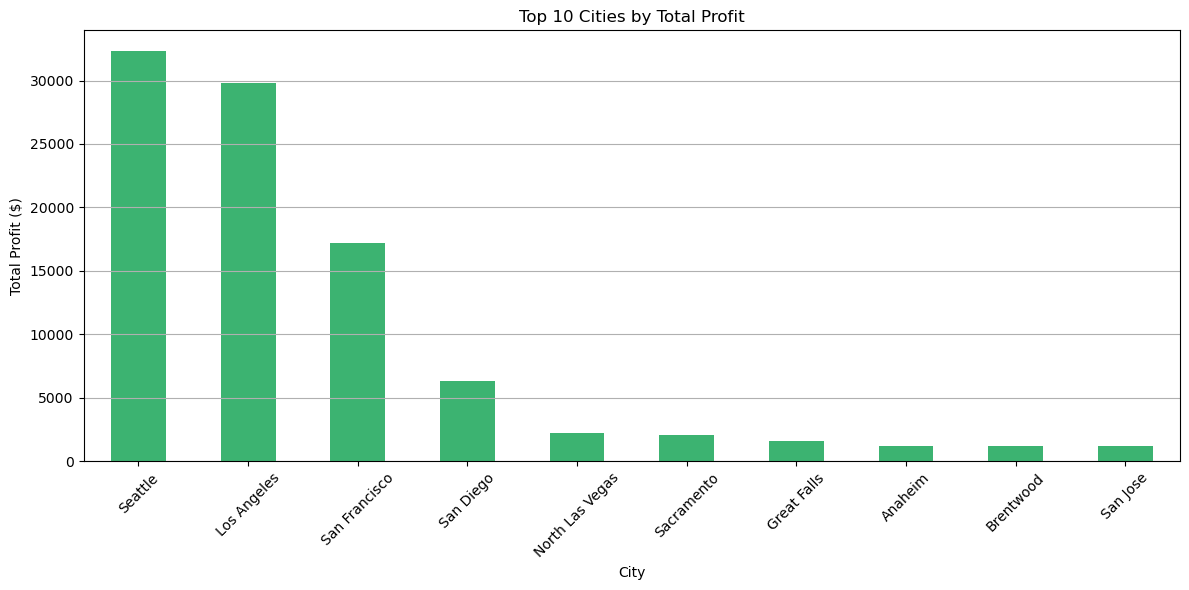

In [29]:
import matplotlib.pyplot as plt

top_10_profit_cities = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_10_profit_cities.plot(kind='bar', color='mediumseagreen')
plt.title("Top 10 Cities by Total Profit")
plt.ylabel("Total Profit ($)")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

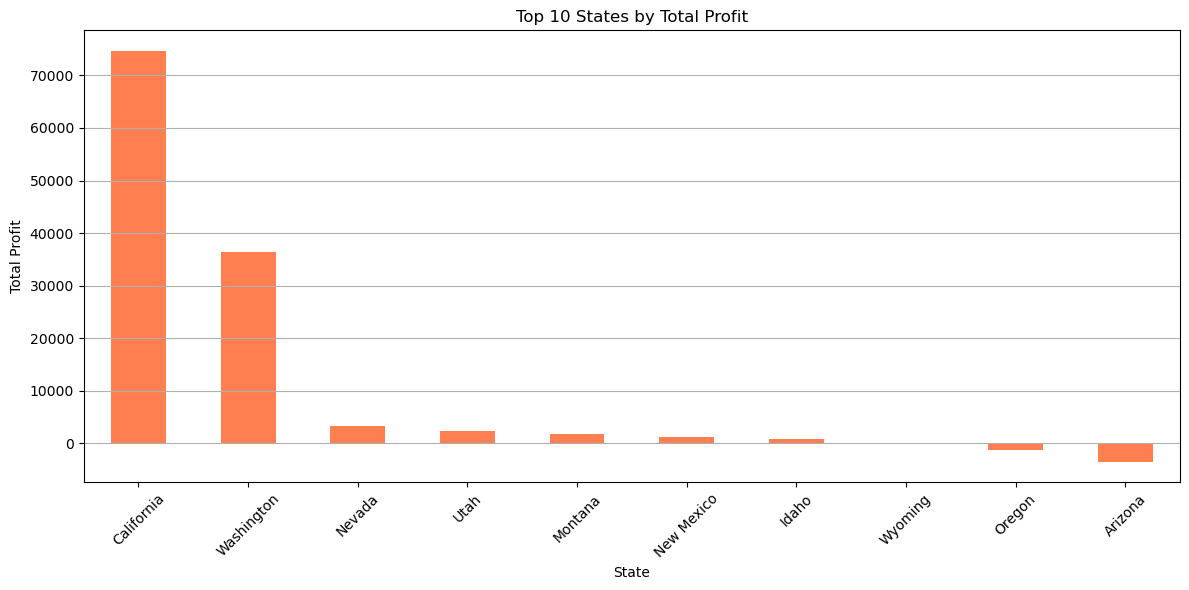

In [47]:
import matplotlib.pyplot as plt

top_10_profit_States = df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_10_profit_States.plot(kind='bar', color='coral')
plt.title("Top 10 States by Total Profit")
plt.ylabel("Total Profit")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [21]:
df['order_date_clean'] = pd.to_datetime(df['order_date_clean'], errors='coerce')

In [23]:
total_sales_2011 = df[df['order_date_clean'].dt.year == 2011]['Sales'].sum()
print(f"total_sales_2011: {total_sales_2011}")

total_sales_2011: 151892.217


In [27]:
total_sales_2012 = df[df['order_date_clean'].dt.year == 2012]['Sales'].sum()
print(f"total_sales_2012: {total_sales_2012}")

total_sales_2012: 139652.3395


In [31]:
total_sales_2013 = df[df['order_date_clean'].dt.year == 2013]['Sales'].sum()
print(f"total_sales_2013: {total_sales_2013}")

total_sales_2013: 187636.4005


In [35]:
total_sales_2014 = df[df['order_date_clean'].dt.year == 2014]['Sales'].sum()
print(f"total_sales_2014: {total_sales_2014}")

total_sales_2014: 250838.2435
